<a href="https://colab.research.google.com/github/FaridRash/eurusd-regression-forecasting/blob/main/Farid/Farid_TS_1st.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!git clone https://github.com/FaridRash/eurusd-regression-forecasting

Cloning into 'eurusd-regression-forecasting'...
remote: Enumerating objects: 86, done.
remote: Counting objects: 100% (86/86), done.
remote: Compressing objects: 100% (69/69), done.
remote: Total 86 (delta 35), reused 12 (delta 2), pack-reused 0 (from 0)
Receiving objects: 100% (86/86), 5.23 MiB | 6.32 MiB/s, done.
Resolving deltas: 100% (35/35), done.


In [2]:
import pandas as pd

df = pd.read_csv('/content/eurusd-regression-forecasting/Dataset/EURUSD-2000-2020-15m.csv')
display(df.head())

,DATE_TIME,HIGH,LOW,OPEN,CLOSE
0,2000.01.03 00:00:00,1.0080,1.0073,1.0073,1.0077
1,2000.01.03 00:15:00,1.0087,1.0076,1.0078,1.0086
2,2000.01.03 00:30:00,1.0089,1.0079,1.0087,1.0079
3,2000.01.03 00:45:00,1.0132,1.0078,1.0078,1.0128
4,2000.01.03 01:00:00,1.0133,1.0120,1.0129,1.0122


#NaN and Duplicate

In [3]:
# 1) Ensure datetime index (if not already done)
df['DATE_TIME'] = pd.to_datetime(df['DATE_TIME'])
df = df.set_index('DATE_TIME').sort_index()

In [4]:
# 2) Look for duplicate timestamps
dup_count = df.index.duplicated().sum()
print(f"Duplicate timestamps: {dup_count}")

# (If any) keep the last occurrence for each timestamp
if dup_count > 0:
    df = df[~df.index.duplicated(keep='last')]
    print("Duplicates removed by keeping the last occurrence per timestamp.")

Duplicate timestamps: 0


In [5]:
# 3) Quick NA check
print("\nMissing values per column:")
print(df.isna().sum())


Missing values per column:
HIGH     0
LOW      0
OPEN     0
CLOSE    0
dtype: int64


#Mark gaps and split into contiguous blocks

In [6]:
# 1) how many 15-min steps since previous row
step = df.index.to_series().diff().dt.total_seconds().div(15*60)
df['gap_steps'] = step.fillna(1).astype(int)

In [7]:
# 2) flag gaps (anything > 1 step)
df['is_gap'] = df['gap_steps'] > 1

In [8]:
# 3) contiguous block id (increments when a gap starts)
df['block_id'] = df['is_gap'].cumsum()

In [9]:
# quick sanity
print(df[['gap_steps','is_gap','block_id']].head(10))
print("\n# of contiguous blocks:", df['block_id'].nunique())
print("Example blocks and sizes:")
print(df.groupby('block_id').size().head())

                     gap_steps  is_gap  block_id
DATE_TIME                                       
2000-01-03 00:00:00          1   False         0
2000-01-03 00:15:00          1   False         0
2000-01-03 00:30:00          1   False         0
2000-01-03 00:45:00          1   False         0
2000-01-03 01:00:00          1   False         0
2000-01-03 01:15:00          1   False         0
2000-01-03 01:30:00          1   False         0
2000-01-03 01:45:00          1   False         0
2000-01-03 02:00:00          1   False         0
2000-01-03 02:15:00          1   False         0

# of contiguous blocks: 1249
Example blocks and sizes:
block_id
0    109
1     40
2    329
3    257
4    222
dtype: int64


#ARIMA

##change 15 to daily

In [ ]:
"""
1. Started with 15-minute candles (huge dataset with weekend gaps).

2. To prepare for ARIMA (which needs regular daily data), we:

3. Resampled from 15-minute to 1 day frequency.

4. Picked the last CLOSE price of each day (end-of-day value).

5. Found some days with NaN (weekends & holidays).

6. Dropped those NaN days, so now we have only valid trading days.

6. Final result = a clean daily CLOSE time series (5,255 days from 2000–2020).
"""

In [10]:
# Step A1: Resample to daily CLOSE
# We'll use the last CLOSE of each day (end of trading day)

df_daily = df['CLOSE'].resample('1D').last()

print(df_daily.head(10))
print("\nShape:", df_daily.shape)
print("Date range:", df_daily.index.min(), "→", df_daily.index.max())

DATE_TIME
2000-01-03    1.0246
2000-01-04    1.0292
2000-01-05    1.0326
2000-01-06    1.0330
2000-01-07    1.0298
2000-01-08       NaN
2000-01-09       NaN
2000-01-10    1.0251
2000-01-11    1.0336
2000-01-12    1.0308
Freq: D, Name: CLOSE, dtype: float64

Shape: (7382,)
Date range: 2000-01-03 00:00:00 → 2020-03-19 00:00:00


In [11]:
# Drop NaN days (weekends/holidays)
df_daily = df_daily.dropna()

In [12]:
print(df_daily.head(10))
print("\nShape:", df_daily.shape)
print("Date range:", df_daily.index.min(), "→", df_daily.index.max())

DATE_TIME
2000-01-03    1.0246
2000-01-04    1.0292
2000-01-05    1.0326
2000-01-06    1.0330
2000-01-07    1.0298
2000-01-10    1.0251
2000-01-11    1.0336
2000-01-12    1.0308
2000-01-13    1.0260
2000-01-14    1.0122
Name: CLOSE, dtype: float64

Shape: (5255,)
Date range: 2000-01-03 00:00:00 → 2020-03-19 00:00:00


##Visualization & Stationarity Check

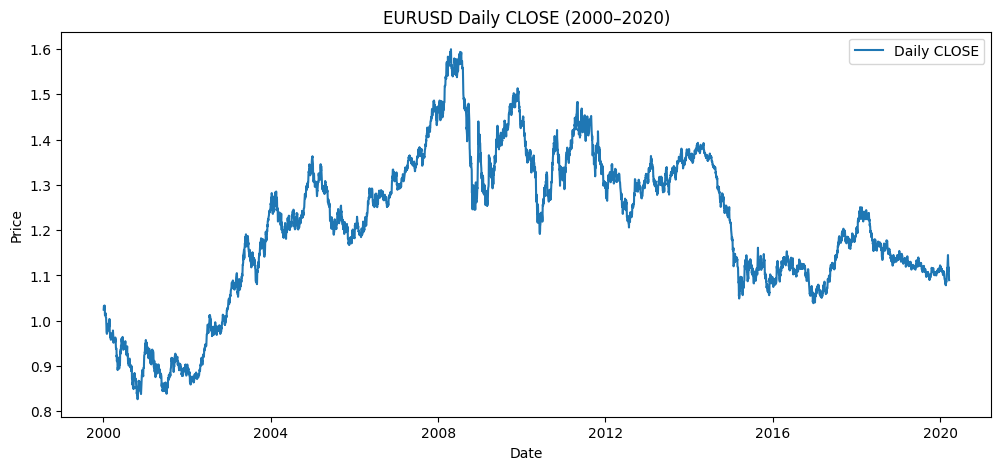

ADF Statistic: -1.692399883190312
p-value: 0.4350324786323302
Critical Value 1%: -3.4315954784667735
Critical Value 5%: -2.8620903726378546
Critical Value 10%: -2.567062963019618


In [13]:
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller

# 1) Plot the daily CLOSE
plt.figure(figsize=(12,5))
plt.plot(df_daily, label='Daily CLOSE')
plt.title('EURUSD Daily CLOSE (2000–2020)')
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.show()

# 2) Augmented Dickey-Fuller test
result = adfuller(df_daily)
print("ADF Statistic:", result[0])
print("p-value:", result[1])
for key, value in result[4].items():
    print(f'Critical Value {key}: {value}')

In [ ]:
"""
1. The plot

EURUSD daily CLOSE (2000–2020) clearly shows trends and cycles.

Example: strong uptrend 2002–2008, downtrend after 2014.

This visual already suggests the series is not stationary (mean changes over time).

2. The ADF test

ADF Statistic = -1.69

p-value = 0.45 (way above 0.05)

Critical values at 1%, 5%, 10% are much lower than our statistic.


Interpretation:

Null hypothesis (series has a unit root = not stationary) cannot be rejected.

So the series is NOT stationary.
"""